In [1]:
import numpy as np
import pandas as pd
import pickle as pkl
from purged_cv import *
import matplotlib.pyplot as plt
from Labeling import *
from purged_cv_by_date import *

# 1. Train Primary Model to Predict up/down movement at events

In the first step we use a Random Forest Model to predict given the Features at an event wether the stock goes up or down, wether to go long or short at that event. 
We ignored events with the same price level at vertical barrier, as the label 0 in this case would indicate doing nothing, which is later done by using a secondary model to predict wether Trade should be made or not. 

## Extract Trading Dates and Prices

In [111]:
with open("./Data/stocks.pkl", "rb") as file: 
    stocks = pkl.load(file)

In [112]:
trading_days = pd.to_datetime(stocks["Date"]).unique()

In [113]:
prices = stocks[["PERMNO", "Date", "DlyClose"]]

In [114]:
prices = prices.set_index(["Date", "PERMNO"], drop=True)
prices = prices.loc[~prices.index.duplicated(keep='first'), :]

In [115]:
prices

,,DlyClose
Date,PERMNO,
2013-01-02,10026,64.3200
2013-01-03,10026,64.6800
2013-01-04,10026,64.7700
2013-01-07,10026,63.4007
2013-01-08,10026,63.4300
...,...,...
2023-12-22,93429,175.5300
2023-12-26,93429,173.6900
2023-12-27,93429,175.6100


## Read in Side-labeled Data

In [2]:
with open("./Data/feature_scores_events.pkl", "rb") as file:
    data = pkl.load(file)

In [3]:
data.describe()

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,vol_z,turnover_proxy,vwap_proxy,pv_corr,pv_divergence,label,DlyClose,End Time,timestamp,Side
count,688064,688064.000000,688064.000000,688064.000000,688064.000000,688064.000000,688064.000000,688064.000000,688064.000000,688064.000000,...,688064.000000,688064.000000,688064.000000,688064.000000,688064.000000,688064.000000,688064.000000,688064,688064,688064.000000
mean,2018-08-07 20:41:50.557157632,66194.488372,0.006385,0.006438,0.007964,0.006395,0.006378,-0.002341,0.006331,0.006231,...,0.333099,0.328736,0.006440,0.003213,-0.003213,0.002897,57.620063,2018-08-12 07:19:58.144358400,2018-08-28 02:42:05.123244288,0.032831
min,2013-04-04 00:00:00,10026.000000,-1.025310,-1.025152,-7.088935,-1.024847,-1.024539,-6.734629,-1.024029,-1.022825,...,-2.145363,-2.128691,-1.027107,-2.491097,-3.332061,-0.950092,0.040600,2013-04-05 00:00:00,2013-04-24 00:00:00,-1.000000
25%,2015-11-24 00:00:00,38093.000000,-0.619527,-0.619594,-0.387768,-0.619721,-0.619872,-0.377466,-0.619968,-0.620378,...,-0.501002,-0.457361,-0.619376,-0.754610,-0.732795,-0.022697,13.020000,2015-12-02 00:00:00,2015-12-14 00:00:00,-1.000000
50%,2018-08-14 00:00:00,81621.000000,-0.317473,-0.317320,-0.013015,-0.317189,-0.317235,-0.027024,-0.316843,-0.316886,...,0.045320,0.032669,-0.317460,-0.026783,0.026783,0.001393,31.930000,2018-08-17 00:00:00,2018-09-04 00:00:00,1.000000
75%,2021-05-11 00:00:00,89708.000000,0.260395,0.260288,0.387376,0.260678,0.260826,0.355199,0.261125,0.261082,...,0.922985,0.746225,0.259825,0.732795,0.754610,0.024636,66.680000,2021-05-13 00:00:00,2021-06-01 00:00:00,1.000000
max,2023-12-01 00:00:00,93429.000000,6.124177,6.118742,6.570649,6.104151,6.095153,6.785469,6.084156,6.061786,...,4.841811,6.887148,6.140851,3.332061,2.491097,208.852217,3696.060000,2023-12-21 00:00:00,2023-12-21 00:00:00,1.000000
std,NaN,30128.656859,1.003006,1.003037,1.089930,1.003006,1.003002,1.028576,1.002903,1.002804,...,1.168689,1.212860,1.002988,1.012351,1.012351,0.319234,110.104601,NaN,NaN,0.999462


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688064 entries, 0 to 688063
Data columns (total 55 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                688064 non-null  datetime64[ns]
 1   PERMNO              688064 non-null  int64         
 2   ma_5                688064 non-null  float64       
 3   ema_5               688064 non-null  float64       
 4   slope_ma_5          688064 non-null  float64       
 5   ma_10               688064 non-null  float64       
 6   ema_10              688064 non-null  float64       
 7   slope_ma_10         688064 non-null  float64       
 8   ma_20               688064 non-null  float64       
 9   ema_20              688064 non-null  float64       
 10  slope_ma_20         688064 non-null  float64       
 11  ma_60               688064 non-null  float64       
 12  ema_60              688064 non-null  float64       
 13  slope_ma_60         688064 no

In [5]:
data.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'End Time', 'timestamp', 'Side'],
      dtype='object')

## 1.1 Hyperparameter Tuning for Random Forest using Smaller Time Period

In [61]:
data_cv = data[(data["Date"]>= "2016-01-01") & (data["Date"]<= "2017-01-01")]

In [72]:
#drop forward looking columns from Features
X_cv = data_cv.drop(columns=["PERMNO", "label", "End Time", "timestamp", "Side"])
y_cv = data_cv["Side"]

In [73]:
#iterable Hyperparameter Combinations
cv_params = {'max_depth': [3, 5, 7, None], 
             'min_samples_leaf': [3, 5], #2, 3, 
             'n_estimators': [100, 200, 300]
             }  

params_comb = param_grid_dicts(cv_params)

In [74]:
purge_days = 60  # or 20, 40, whatever you used

df_cv = X_cv.sort_values('Date').copy()  # the same df you passed to CV
folds = purged_kfold_indices_by_date(df_cv, date_col='Date', 
                                     n_splits=5, purge_days=purge_days)

for i, (train_idx, test_idx) in enumerate(folds):
    train_dates = df_cv.iloc[train_idx]['Date']
    test_dates  = df_cv.iloc[test_idx]['Date']

    min_test = test_dates.min()
    max_test = test_dates.max()

    lower_purge = min_test - pd.Timedelta(days=purge_days)
    upper_purge = max_test + pd.Timedelta(days=purge_days)

    # any train dates inside purge window?
    violation = train_dates[(train_dates >= lower_purge) & (train_dates <= upper_purge)]

    print(f"Fold {i}: violations = {len(violation)}")


Fold 0: violations = 0
Fold 1: violations = 0
Fold 2: violations = 0
Fold 3: violations = 0
Fold 4: violations = 0


In [59]:
from sklearn.ensemble import RandomForestClassifier
from purged_cv import purged_kfold_indices
from sklearn.metrics import f1_score

#Use Date based purged CV using 60 Day purge size, given that max horizon used in feature computation is 60 day window.
n_splits = 5
folds = purged_kfold_indices_by_date(X_cv, n_splits=n_splits, purge_days= 60)

#now drop date
X_cv = X_cv.drop(columns=["Date"])

results = []

for params in params_comb:
    print(params)

    weighted_f1_scores = []
    avg_pred_prob = [] 

    for fold, (train_idx, test_idx) in enumerate(folds, 1):
        
        # Extract training and test data for this fold.
        X_t, y_t = X_cv.iloc[train_idx , : ], y_cv.iloc[train_idx]
        X_val, y_val = X_cv.iloc[test_idx, : ], y_cv.iloc[test_idx]

        # Fit the model using XGBRegressor.
        model = RandomForestClassifier(n_estimators = params["n_estimators"], 
                                       min_samples_leaf=params["min_samples_leaf"],
                                       max_depth=params["max_depth"],
                                       class_weight='balanced',
                                       n_jobs=-1,
                                       random_state=42)
        
        model.fit(X_t, y_t)

        #compute 
        y_pred = model.predict(X_val)

        weighted_f1 = f1_score(y_pred=y_pred, y_true=y_val, average="weighted")
        prob = np.max(model.predict_proba(X_val) , axis = 1)

        weighted_f1_scores.append(weighted_f1)
        avg_pred_prob.append(np.mean(prob))

    mean_F1 = np.mean(weighted_f1_scores)
    mean_prob = np.mean(avg_pred_prob)
    
    result_entry = {
        **params,
        "weighted F1" : mean_F1,
        "avg confidence" : mean_prob,
    }

    results.append(result_entry)
    print(f"mean F1 Score: {mean_F1},  mean Confidence: {mean_prob}")


{'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 100}
mean F1 Score: 0.5630831734221464,  mean Confidence: 0.5167024807750296
{'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200}
mean F1 Score: 0.5649088658006891,  mean Confidence: 0.5161752589988345
{'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 300}
mean F1 Score: 0.5651254154380124,  mean Confidence: 0.5159783175062385
{'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100}
mean F1 Score: 0.562706667729014,  mean Confidence: 0.5166991437819839
{'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
mean F1 Score: 0.5649620766512615,  mean Confidence: 0.5161740110132615
{'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 300}
mean F1 Score: 0.5648868737115234,  mean Confidence: 0.5159764620954788
{'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100}
mean F1 Score: 0.583119800388479,  mean Confidence: 0.525547087198371
{'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 200}
mean F1 Sco

In [75]:
#sort according to best average weighted F1 Score
df_results = pd.DataFrame(results).sort_values(by="weighted F1", ascending=False)
df_results

,max_depth,min_samples_leaf,n_estimators,weighted F1,avg confidence
23,NaN,5,300,0.641002,0.582041
20,NaN,3,300,0.639535,0.585621
22,NaN,5,200,0.637688,0.583016
19,NaN,3,200,0.637526,0.586883
21,NaN,5,100,0.632830,0.586712
18,NaN,3,100,0.631672,0.591138
14,7.0,3,300,0.605578,0.533729
13,7.0,3,200,0.604344,0.534119
17,7.0,5,300,0.602845,0.533744
12,7.0,3,100,0.601400,0.534632


Based on the Hyperparameter Tuning, the Hyperparameter among the best performing ones, that regularize the tree the most to avoid overfitting. 
As criterion we choose the weighted F1 Score and the average probability of the class label with the highest probability, which is interpreted as confidence.
Thus The Parameter configuration: max_depth: 7, min_samples_leaf: 5, and n_estimators = 100 and max_depth: None, min_samples_leaf:5, n_estimators 100 are considered for the final model. 

## 1.2 Train Primary Model with purged CV - Random Forest

In [140]:
data = data.sort_values("Date").reset_index(drop = True)

X_TRAIN = data.loc[data['Date'] < '2021-01-01'].copy()
X_TEST  = data.loc[data['Date'] >= '2021-04-01'].copy() #Introduce Purging into Training and Test Set - no leakage

In [79]:
X = X_TRAIN.drop(columns = ["PERMNO", "label", "End Time", "timestamp", "Side"])
Y = X_TRAIN["Side"]

In [80]:
X.columns

Index(['Date', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10', 'slope_ma_10',
       'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60', 'slope_ma_60',
       'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif', 'macd_dea', 'macd',
       'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower', 'bb_pctB', 'rsi',
       'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10', 'aroon_up_20',
       'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev', 'gap_cc_prev',
       'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c', 'ret_co',
       'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy', 'vwap_proxy',
       'pv_corr', 'pv_divergence', 'DlyClose'],
      dtype='object')

In [85]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

# Fit the Primary model on the Training Data only to create out-of-sample prediction using predicition and probabilities on test set using purged CV
# for the Side Label that is later used in the meta model.
n_samples = X.shape[0]
n_splits = 5

folds = purged_kfold_indices_by_date(
    df=X,
    n_splits=n_splits,
    purge_days=60
)

#Now drop Date
X_tr = X.drop(columns = ["Date"])  
y_tr = Y


# Arrays for out-of-sample prediction and Probability for each Label
oof_proba = np.zeros((n_samples, len(np.unique(y_tr)))) # class probabilities
oof_pred  = np.zeros(n_samples)  # hard labels

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    
    print(f"Fold {fold}")

    X_t, y_t = X_tr.iloc[train_idx , : ], y_tr.iloc[train_idx]
    X_val, y_val = X_tr.iloc[val_idx, : ], y_tr.iloc[val_idx]

    primary = RandomForestClassifier(
        n_estimators   = 100,
        min_samples_leaf = 5,
        max_depth      = None,
        class_weight   = 'balanced',
        n_jobs         = -1,
        random_state   = 42,
    )

    primary.fit(X_t, y_t)

    # Out-of-sample predictions for this fold
    proba_val = primary.predict_proba(X_val)
    pred_val = primary.predict(X_val)

    oof_proba[val_idx, :] = proba_val
    oof_pred[val_idx]     = pred_val

avg_confidence = np.mean(np.max(oof_proba, axis=1))
print(f"OOF average confidence: {avg_confidence:.4f}")

print(classification_report(y_tr, oof_pred))


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
OOF average confidence: 0.5523
              precision    recall  f1-score   support

        -1.0       0.49      0.43      0.46    235885
         1.0       0.53      0.59      0.56    257534

    accuracy                           0.52    493419
   macro avg       0.51      0.51      0.51    493419
weighted avg       0.51      0.52      0.51    493419



In [86]:
X_TRAIN.loc[:,"pred_Side"] = oof_pred
X_TRAIN.loc[:,"pred_Side_proba"] = np.max(oof_proba, axis=1)

/var/folders/zb/_v_3sbq938jftd_b07f5kpfm0000gn/T/ipykernel_92325/4067300904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_TRAIN.loc[:,"pred_Side"] = oof_pred
/var/folders/zb/_v_3sbq938jftd_b07f5kpfm0000gn/T/ipykernel_92325/4067300904.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_TRAIN.loc[:,"pred_Side_proba"] = np.max(oof_proba, axis=1)


In [87]:
#Check Label Assignment
equal = (X_TRAIN["Side"] == X_TRAIN["pred_Side"]).sum()
accuracy = equal / len(X_TRAIN["Side"])
accuracy

np.float64(0.5159955332080848)

## 1.3 ROC Curve

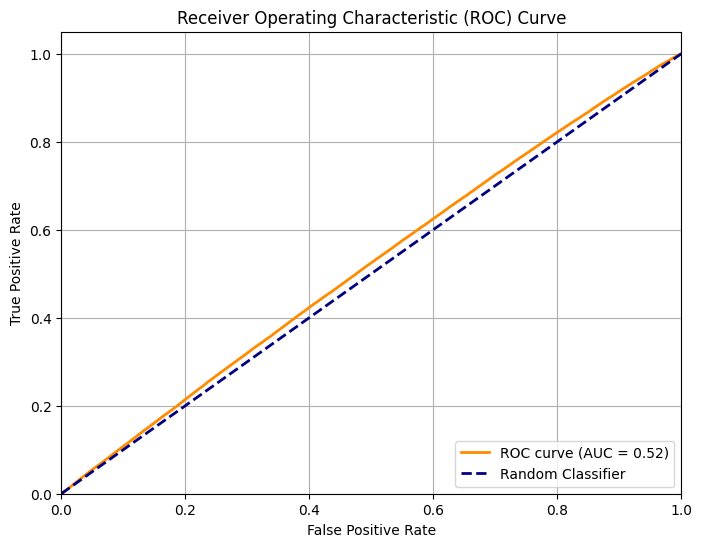

In [88]:
from sklearn.metrics import roc_curve, auc

#Get predicted probabilities for the positive class (class 1)
y_pred_proba = oof_proba[:, 1]

# 5. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(X_TRAIN["Side"], y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 1.4 Fit Primary Model on complete Training Dataset

In [91]:
X_train_full_primary = X_TRAIN.drop(columns=["Date","PERMNO", "label", "End Time","timestamp", "pred_Side","pred_Side_proba", "Side"])
Y_train_full_primary = X_TRAIN["Side"].values

# Fit Primary Model on complete Training Data
primary_full = RandomForestClassifier(
        n_estimators   = 100,
        min_samples_leaf = 5,
        max_depth      = None,
        class_weight   = 'balanced',
        n_jobs         = -1,
        random_state   = 42,
    )

primary_full.fit(X_train_full_primary, Y_train_full_primary) 


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 1.5 Feature Importance

In [123]:
importances = primary.feature_importances_
feat_imp = pd.Series(importances, index=X_train_full_primary.columns).sort_values(ascending=False)

# Look at the top features numerically
print(feat_imp.head(20))

shadow_lower_ratio    0.034047
shadow_upper_ratio    0.033354
macd_cross            0.031325
aroon_down_10         0.028028
aroon_down_20         0.027674
aroon_up_10           0.025774
aroon_up_20           0.024380
rsv_10                0.023726
gap_oc_prev           0.023458
slope_ma_60           0.023355
range_hl_over_c       0.023052
dvol                  0.023001
ret_oc                0.022999
adv                   0.022935
slope_ma_5            0.022866
vol                   0.022806
macd                  0.022750
ret_5                 0.022524
rsv_20                0.022496
rsi                   0.022421
dtype: float64


# 2. Train Secondary Model on out-of-sample Side predictions - Random Forest

In [92]:
permno_list = X_TRAIN["PERMNO"].unique()

In [93]:
data_indexed = X_TRAIN.set_index(["Date", "PERMNO"], drop=False)
data_indexed = data_indexed.sort_index(level=0)

In [116]:
from Labeling import *
# Based on the Out of Sample Prediction for the Training Data obtained using pruged CV,
# label the event [1,0] if profitable or not.
data_meta_dict = {}

for id in permno_list:
    data_sub = data_indexed.xs(id, level="PERMNO").sort_index()
    prices_sub = prices.xs(id, level="PERMNO").sort_index()
    labels = meta_labeling(data_sub, prices_sub["DlyClose"])
    labeled_events = pd.merge(data_sub, labels, left_index=True, right_index=True)
    data_meta_dict[id] = labeled_events

In [117]:
X_TRAIN = pd.concat(data_meta_dict, ignore_index=True)

In [118]:
X_TRAIN

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,pv_divergence,label,DlyClose,End Time,timestamp,Side,pred_Side,pred_Side_proba,Return of Label,Label
0,2013-04-04,75591,0.495746,0.495786,-0.622837,0.509141,0.501209,-0.837572,0.503677,0.500104,...,-0.361431,0.021038,51.81,2013-04-10,2013-04-24,1.0,1.0,0.629762,0.021424,1.0
1,2013-04-10,75591,0.494348,0.496296,0.646358,0.497181,0.498129,-0.201686,0.505493,0.498631,...,-0.185511,-0.048753,52.92,2013-04-15,2013-04-30,-1.0,1.0,0.544915,-0.041761,0.0
2,2013-04-15,75591,0.494213,0.491643,-0.555309,0.491876,0.494931,-0.510685,0.505179,0.496871,...,0.291705,-0.012226,50.71,2013-04-16,2013-05-06,1.0,1.0,0.722931,0.020114,1.0
3,2013-04-18,75591,0.481764,0.479481,-0.759854,0.488512,0.486130,-0.680107,0.498971,0.491530,...,-0.494455,0.036451,49.93,2013-04-24,2013-05-08,1.0,1.0,0.625810,0.031444,1.0
4,2013-04-24,75591,0.482493,0.488051,0.340786,0.485277,0.487652,-0.583873,0.491683,0.490735,...,-0.858213,-0.014757,51.50,2013-05-03,2013-05-14,1.0,1.0,0.528830,0.025049,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493414,2020-12-01,91498,0.155508,0.142350,-1.234056,0.145681,0.146134,-0.678824,0.145062,0.157542,...,0.023294,0.065430,71.68,2020-12-02,2020-12-21,1.0,-1.0,0.570096,-0.056920,0.0
493415,2020-12-03,91498,0.148715,0.142358,-0.526288,0.148880,0.144243,0.333200,0.143000,0.154374,...,-0.198908,-0.047150,76.14,2020-12-09,2020-12-23,-1.0,1.0,0.563826,-0.039138,0.0
493416,2020-12-10,91498,0.116034,0.111959,-1.696169,0.132224,0.123247,-1.345530,0.131537,0.135313,...,-0.004006,0.001241,72.55,2020-12-30,2020-12-30,-1.0,1.0,0.501907,-0.031564,0.0
493417,2020-12-24,91498,0.076881,0.081313,0.459224,0.076252,0.084182,0.004926,0.103777,0.098038,...,-0.547396,-0.060487,73.90,2020-12-29,2021-01-13,-1.0,1.0,0.607978,-0.038430,0.0


In [119]:
X_TRAIN["Label"].value_counts()

Label
1.0    250669
0.0    242750
Name: count, dtype: int64

In [120]:
#include predicted Side and Probabilities in Meta Model

X_meta = X_TRAIN.drop(columns=["Date","PERMNO","label", "End Time","timestamp", "Return of Label", "Label", "Side"])
Y_meta = X_TRAIN["Label"].values

In [122]:
from sklearn.metrics import f1_score

#Fit the Meta Model on the Training Set.
secondary  = RandomForestClassifier(
    n_estimators   = 100,
    min_samples_leaf = 5,
    max_depth      = None,
    class_weight   = 'balanced',
    n_jobs         = -1,
    random_state   = 42,
)

secondary.fit(X_meta, Y_meta)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 3. Backtesting the Strategy

## 3.1 Side and Label Prediction on Test Set

In [141]:
X_test = X_TEST.drop(columns=["Date", "PERMNO","label", "End Time", "timestamp", "Side"])
Y_train = X_TEST["Side"].values

In [142]:
# Primary predictions on held-out test
side_proba= primary_full.predict_proba(X_test)
side_pred = primary_full.predict(X_test)

In [143]:
X_test.loc[: , "pred_Side"] = side_pred
X_test.loc[: , "pred_Side_proba"] = np.max(side_proba, axis=1)

X_TEST.loc[: , "pred_Side"] = side_pred
X_TEST.loc[: , "pred_Side_proba"] = np.max(side_proba, axis=1)

In [144]:
label = secondary.predict(X_test)
label_prob = np.max(secondary.predict_proba(X_test) , axis = 1) 

In [147]:
X_TEST.loc[: , "pred_Label"] = label
X_TEST.loc[: , "pred_Label_proba"] = label_prob
X_TEST

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,pv_divergence,label,DlyClose,End Time,timestamp,Side,pred_Side,pred_Side_proba,pred_Label,pred_Label_proba
509797,2021-04-01,24441,-0.641735,-0.641929,-0.330655,-0.644646,-0.645131,-0.301419,-0.653822,-0.647856,...,-0.433016,0.013859,9.380,2021-04-15,2021-04-21,1.0,-1.0,0.576436,1.0,0.518370
509798,2021-04-01,84072,-0.637764,-0.638295,-0.265037,-0.642375,-0.642300,-0.219098,-0.651948,-0.645105,...,-0.805298,0.034836,9.760,2021-04-09,2021-04-21,1.0,-1.0,0.530274,0.0,0.504944
509799,2021-04-01,33099,-0.482360,-0.483498,-0.224820,-0.489173,-0.487501,0.076184,-0.494023,-0.492922,...,1.536899,-0.019048,25.200,2021-04-21,2021-04-21,1.0,1.0,0.503023,0.0,0.521514
509800,2021-04-01,12654,-0.119807,-0.119218,-0.140576,-0.116226,-0.118593,-0.104027,-0.120603,-0.118060,...,0.430957,0.012831,60.948,2021-04-05,2021-04-21,1.0,1.0,0.550545,0.0,0.511582
509801,2021-04-01,13296,-0.611147,-0.611636,-0.385689,-0.614681,-0.615099,-0.170779,-0.624351,-0.617604,...,-0.313519,0.000000,12.200,2021-04-21,2021-04-21,1.0,1.0,0.528346,1.0,0.512156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688059,2023-12-01,88853,-0.303486,-0.304041,-0.046255,-0.303026,-0.304507,-0.233637,-0.307423,-0.307291,...,1.182504,-0.021282,39.000,2023-12-05,2023-12-21,-1.0,-1.0,0.523505,0.0,0.558525
688060,2023-12-01,16548,-0.101779,-0.096349,1.844358,-0.110621,-0.106115,0.975709,-0.115782,-0.117028,...,-0.848359,0.049201,62.600,2023-12-07,2023-12-21,1.0,-1.0,0.564031,0.0,0.540921
688061,2023-12-01,92007,-0.013132,-0.012445,0.201528,-0.014743,-0.013555,0.109587,-0.014296,-0.013085,...,0.074832,-0.002556,68.460,2023-12-05,2023-12-21,-1.0,-1.0,0.503360,0.0,0.594120
688062,2023-12-01,91271,-0.482344,-0.483384,-0.317797,-0.481793,-0.483511,-0.376455,-0.485968,-0.486952,...,1.050349,0.004352,20.680,2023-12-11,2023-12-21,1.0,1.0,0.516087,0.0,0.562307


In [154]:
with open('./Data/scores_test_side_meta_labeled_rf.pkl', 'wb') as file:
    pkl.dump(X_TEST, file)

## 3.2 Quality of Strategy

In [216]:
with open('./Data/scores_test_side_meta_labeled_rf.pkl', 'rb') as file:
    X_backtest = pkl.load(file)

In [177]:
import numpy as np
import pandas as pd

def count_trading_days_per_event(
    trading_days: pd.DatetimeIndex,
    event_start: pd.Series | np.ndarray,
    event_end: pd.Series | np.ndarray,
) -> np.ndarray:
    """
    Count number of trading days between event_start and event_end for each event.

    trading_days: sorted DatetimeIndex of valid trading days
    event_start, event_end: same length, datetime-like (Series or array)
    """
    # Make sure these are arrays of Timestamps
    start_vals = pd.to_datetime(event_start).to_numpy()
    end_vals   = pd.to_datetime(event_end).to_numpy()

    # Position of first trading day >= start
    start_idx = trading_days.searchsorted(start_vals, side="left")

    # Position of last trading day <= end
    end_idx = trading_days.searchsorted(end_vals, side="right") - 1

    # Clip to valid range in case start/end are outside trading_days
    start_idx = np.clip(start_idx, 0, len(trading_days) - 1)
    end_idx   = np.clip(end_idx,   0, len(trading_days) - 1)

    # Number of trading days (if end before start, set to 0)
    n_days = end_idx - start_idx + 1
    n_days = np.where(n_days < 0, 0, n_days)

    return n_days


In [217]:
def return_of_Label(
    events: pd.DataFrame,
    close: pd.Series,
    Threshold = 0.55
) -> pd.DataFrame:

    events_filtered = events.dropna(subset=['End Time'])
    all_dates = events_filtered.index.union(events_filtered['End Time'].values).drop_duplicates()
    close_filtered = close.reindex(all_dates, method='bfill')
    out = pd.DataFrame(index=events_filtered.index)


    #Return of Label: close price at end time/ close price at start time - 1.
    out['Return of Label'] = close_filtered.loc[events_filtered['End Time'].values].values / close_filtered.loc[events_filtered.index] - 1
    out['Return of Label'] *= events_filtered['pred_Side']

    #return of each event
    out["event_ret"] = out['Return of Label'] * events_filtered['pred_Label'] * events_filtered['pred_Label_proba'] #return daily returns. If investment horizon is longer then 1 day divide returns by size of investment window.
    
    #If Probability to Trade less then threshold set value to zero --> No Trade
    out.loc[events_filtered["pred_Label_proba"] <= Threshold, "event_ret"] = 0

    #compute return of events in daily returns.
    out["event_days"] = count_trading_days_per_event(trading_days, events_filtered.index, events_filtered["End Time"])

    out["event_ret_dly"] = out["event_ret"] / out["event_days"]

    return out

In [218]:
# Compute Return of Label.
X_backtest = X_backtest.set_index(["Date", "PERMNO"])
X_backtest

ma_5     ema_5  slope_ma_5     ma_10    ema_10  \
Date       PERMNO                                                       
2021-04-01 24441  -0.641735 -0.641929   -0.330655 -0.644646 -0.645131   
           84072  -0.637764 -0.638295   -0.265037 -0.642375 -0.642300   
           33099  -0.482360 -0.483498   -0.224820 -0.489173 -0.487501   
           12654  -0.119807 -0.119218   -0.140576 -0.116226 -0.118593   
           13296  -0.611147 -0.611636   -0.385689 -0.614681 -0.615099   
...                     ...       ...         ...       ...       ...   
2023-12-01 88853  -0.303486 -0.304041   -0.046255 -0.303026 -0.304507   
           16548  -0.101779 -0.096349    1.844358 -0.110621 -0.106115   
           92007  -0.013132 -0.012445    0.201528 -0.014743 -0.013555   
           91271  -0.482344 -0.483384   -0.317797 -0.481793 -0.483511   
           83143  -0.043817 -0.043861    0.354270 -0.046798 -0.046514   

                   slope_ma_10     ma_20    ema_20  slope_ma_20     ma_60  \
Date       PERMNO                                                           
2021-04-01 24441     -0.301419 -0.653822 -0.647856    -0.398352 -0.633943   
           84072     -0.219098 -0.651948 -0.645105    -0.421067 -0.625564   
           33099      0.076184 -0.494023 -0.492922    -0.258966 -0.498782   
           12654     -0.104027 -0.120603 -0.118060    -0.149728 -0.110672   
           13296     -0.170779 -0.624351 -0.617604    -0.489212 -0.601634   
...                        ...       ...       ...          ...       ...   
2023-12-01 88853     -0.233637 -0.307423 -0.307291    -0.071487 -0.316866   
           16548      0.975709 -0.115782 -0.117028     0.439732 -0.155052   
           92007      0.109587 -0.014296 -0.013085    -0.094678 -0.008908   
           91271     -0.376455 -0.485968 -0.486952    -0.225760 -0.500677   
           83143      0.289261 -0.052301 -0.049024     0.106986 -0.052284   

                   ...  pv_divergence     label  DlyClose   End Time  \
Date       PERMNO  ...                                                 
2021-04-01 24441   ...      -0.433016  0.013859     9.380 2021-04-15   
           84072   ...      -0.805298  0.034836     9.760 2021-04-09   
           33099   ...       1.536899 -0.019048    25.200 2021-04-21   
           12654   ...       0.430957  0.012831    60.948 2021-04-05   
           13296   ...      -0.313519  0.000000    12.200 2021-04-21   
...                ...            ...       ...       ...        ...   
2023-12-01 88853   ...       1.182504 -0.021282    39.000 2023-12-05   
           16548   ...      -0.848359  0.049201    62.600 2023-12-07   
           92007   ...       0.074832 -0.002556    68.460 2023-12-05   
           91271   ...       1.050349  0.004352    20.680 2023-12-11   
           83143   ...       0.578578 -0.000611    65.490 2023-12-12   

                   timestamp  Side  pred_Side  pred_Side_proba  pred_Label  \
Date       PERMNO                                                            
2021-04-01 24441  2021-04-21   1.0       -1.0         0.576436         1.0   
           84072  2021-04-21   1.0       -1.0         0.530274         0.0   
           33099  2021-04-21   1.0        1.0         0.503023         0.0   
           12654  2021-04-21   1.0        1.0         0.550545         0.0   
           13296  2021-04-21   1.0        1.0         0.528346         1.0   
...                      ...   ...        ...              ...         ...   
2023-12-01 88853  2023-12-21  -1.0       -1.0         0.523505         0.0   
           16548  2023-12-21   1.0       -1.0         0.564031         0.0   
           92007  2023-12-21  -1.0       -1.0         0.503360         0.0   
           91271  2023-12-21   1.0        1.0         0.516087         0.0   
           83143  2023-12-21   1.0        1.0         0.514749         0.0   

                   pred_Label_proba  
Date       PERMNO                    
2021-04-01 24441           0.518370  
     

In [219]:
# Compute Return of Label.
backtest_dict = {}

for id in permno_list: 
    events = X_backtest.xs(id, level="PERMNO").sort_index()
    close = prices.xs(id, level="PERMNO").sort_index()

    ret_label = return_of_Label(events, close, Threshold=0.55)

    t_events = pd.merge(events, ret_label, left_index=True, right_index=True)
    backtest_dict[id] = t_events.reset_index()

In [220]:
df_backtest = pd.concat(backtest_dict, ignore_index=True)

In [221]:
df_backtest

,Date,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,slope_ma_20,...,timestamp,Side,pred_Side,pred_Side_proba,pred_Label,pred_Label_proba,Return of Label,event_ret,event_days,event_ret_dly
0,2021-04-01,1.397912,1.397603,1.824135,1.380322,1.388643,1.921250,1.379400,1.379871,1.280479,...,2021-04-21,1.0,1.0,0.584204,1.0,0.502955,0.013004,0.000000,3,0.000000
1,2021-04-09,1.431879,1.427861,1.218882,1.412524,1.409290,1.686202,1.384680,1.395248,1.957199,...,2021-04-29,1.0,1.0,0.517152,0.0,0.527501,0.014488,0.000000,6,0.000000
2,2021-04-16,1.419525,1.417035,0.696343,1.425747,1.414457,1.004349,1.398504,1.402677,1.549408,...,2021-05-06,1.0,-1.0,0.571170,1.0,0.554837,-0.018407,-0.010213,4,-0.002553
3,2021-04-21,1.434314,1.441318,2.280872,1.428802,1.430041,1.512658,1.413715,1.416052,2.358917,...,2021-05-11,1.0,1.0,0.556311,1.0,0.583045,0.015670,0.009136,7,0.001305
4,2021-04-29,1.440576,1.443169,0.573621,1.439558,1.438611,1.972651,1.433215,1.426329,1.686250,...,2021-05-19,-1.0,-1.0,0.555929,0.0,0.556845,0.017313,0.000000,2,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178262,2023-11-07,-0.600087,-0.601926,-0.555912,-0.602653,-0.604090,-0.368865,-0.609573,-0.608972,0.060591,...,2023-11-27,-1.0,1.0,0.677429,1.0,0.624243,-0.077874,-0.048612,2,-0.024306
178263,2023-11-08,-0.602649,-0.603879,-0.592635,-0.601503,-0.604796,-0.376521,-0.608998,-0.608809,0.018898,...,2023-11-28,-1.0,1.0,0.586018,0.0,0.530048,-0.042895,0.000000,4,0.000000
178264,2023-11-14,-0.606201,-0.605951,-0.516645,-0.604103,-0.606467,-0.566441,-0.606653,-0.609053,-0.294107,...,2023-12-04,-1.0,1.0,0.563950,1.0,0.541295,-0.041199,0.000000,3,0.000000
178265,2023-11-28,-0.606331,-0.606482,-0.230040,-0.607115,-0.606765,-0.412977,-0.606076,-0.608170,-0.532357,...,2023-12-18,1.0,-1.0,0.500242,1.0,0.539038,-0.073333,0.000000,4,0.000000


In [222]:
# Basic stats
mean_ret_daily = df_backtest["event_ret_dly"].mean()
mean_ret = df_backtest["event_ret"].mean()

event_std_ret  = df_backtest["event_ret"].std()
std_ret_daily = df_backtest["event_ret_dly"].std()

n_trades = len(df_backtest[df_backtest["event_ret"] != 0])


# Annualized Sharpe (assuming event frequency ~ daily)
sharpe = mean_ret_daily / std_ret_daily * np.sqrt(252) if std_ret_daily > 0 else np.nan

print(f"Out-of-sample trades: {n_trades}, Total number of Out-of_sample events: {df_backtest.shape[0]}")
print(f"Mean event return: {mean_ret:.6f}")
print(f"Mean daily event return: {mean_ret_daily:.6f}")
print(f"Std event return:  {std_ret_daily:.6f}")
print(f"Annualized Sharpe: {sharpe:.3f}")


Out-of-sample trades: 39652, Total number of Out-of_sample events: 178267
Mean event return: -0.000021
Mean daily event return: -0.000023
Std event return:  0.007451
Annualized Sharpe: -0.050
